# **EXPLORATORY DATA ANALYSIS PROJECT**

## **Introduction:** 

This project uses the Titanic-Dataset.csv dataset to demonstrate the process of data cleaning, handling missing values, data analysis, and visualization using Python. The analysis primarily uses Pandas for data manipulation and cleaning, along with Matplotlib and Seaborn for data visualization. The goal is to explore the Titanic dataset, identify patterns and relationships among key variables, and uncover meaningful insights about the passengers and their survival outcomes.

In [ ]:
# Install matplotlib and seaborn
%pip install matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [33]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## **Task 1: Load the dataset**

In [34]:
# Task 1: Load the Titanic dataset

titanic_data = pd.read_csv("Titanic-Dataset.csv")

## **Task 2: Inspect the dataset**

In [5]:
# Display the first 5 rows of the dataset

print(titanic_data.head())


   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN        S  


In [7]:
# Display the last 5 rows of the dataset

print(titanic_data.tail())

     PassengerId  Survived  Pclass                                      Name  \
886          887         0       2                     Montvila, Rev. Juozas   
887          888         1       1              Graham, Miss. Margaret Edith   
888          889         0       3  Johnston, Miss. Catherine Helen "Carrie"   
889          890         1       1                     Behr, Mr. Karl Howell   
890          891         0       3                       Dooley, Mr. Patrick   

        Sex   Age  SibSp  Parch      Ticket   Fare Cabin Embarked  
886    male  27.0      0      0      211536  13.00   NaN        S  
887  female  19.0      0      0      112053  30.00   B42        S  
888  female   NaN      1      2  W./C. 6607  23.45   NaN        S  
889    male  26.0      0      0      111369  30.00  C148        C  
890    male  32.0      0      0      370376   7.75   NaN        Q  


In [8]:
# Display the dimension and data types of each column

print(titanic_data.info())

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB
None


In [ ]:
# Display summary statistics of the numerical columns
titanic_data.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


## **Task 3: Clean and preprocess the data**

In [64]:
# Create a new categorical feature 'PclassCategory' from 'Pclass'

titanic_data["PclassCategory"] = titanic_data["Pclass"].map({
    1: "First_class",
    2: "Second_class",
    3: "Third_class"
})

# Print the first 5 rows

print(titanic_data[["Pclass", "PclassCategory"]].head())


   Pclass PclassCategory
0       3    Third_class
1       1    First_class
2       3    Third_class
3       1    First_class
4       3    Third_class


In [23]:
# Create a new categorical feature 'CabinCategory' from 'Cabin'

titanic_data["CabinCategory"] = titanic_data["Cabin"].str[0]

print(titanic_data[["CabinCategory", "Cabin"]].head(8))


  CabinCategory Cabin
0           NaN   NaN
1             C   C85
2           NaN   NaN
3             C  C123
4           NaN   NaN
5           NaN   NaN
6             E   E46
7           NaN   NaN


In [ ]:
# Indentify missing values in the 'Age' column 

print("Missing age:\n", titanic_data["Age"].isnull().sum())


Missing age:
 177


In [ ]:
# Handle missing values in the 'Age' column (use mean age)

titanic_data["Age"] = titanic_data["Age"].fillna(titanic_data["Age"].mean())

# Confirm the results

print("Missing age:\n", titanic_data["Age"].isnull().sum())

Missing age:
 0


In [38]:
# Create a 'Family' feature by combining 'SibSp' and 'Parch'

titanic_data["Family"] = titanic_data ["SibSp"] + titanic_data ["Parch"]

# Display the results

print(titanic_data[["SibSp", "Parch", "Family"]].head())


   SibSp  Parch  Family
0      1      0       1
1      1      0       1
2      0      0       0
3      1      0       1
4      0      0       0


## **Task 4: Identify specific data points**

In [36]:
# Find passengers with the highest fare

highest_fare_passengers = titanic_data[titanic_data["Fare"] == titanic_data["Fare"].max()][["Name", "Fare"]]

print(highest_fare_passengers)

                                   Name      Fare
258                    Ward, Miss. Anna  512.3292
679  Cardeza, Mr. Thomas Drake Martinez  512.3292
737              Lesurer, Mr. Gustave J  512.3292


In [41]:
# Find passengers with the largest family size

largest_family_passengers = titanic_data[titanic_data["Family"] == titanic_data["Family"].max()][["Name","Family"]]

print(largest_family_passengers)

                                  Name  Family
159         Sage, Master. Thomas Henry      10
180       Sage, Miss. Constance Gladys      10
201                Sage, Mr. Frederick      10
324           Sage, Mr. George John Jr      10
792            Sage, Miss. Stella Anna      10
846           Sage, Mr. Douglas Bullen      10
863  Sage, Miss. Dorothy Edith "Dolly"      10


## **Task 5: Pandas Series and DataFrame functionalities**

In [ ]:
# Create a Pandas Series of passenger names

names_series = titanic_data["Name"]

print(names_series.head())

0                              Braund, Mr. Owen Harris
1    Cumings, Mrs. John Bradley (Florence Briggs Th...
2                               Heikkinen, Miss. Laina
3         Futrelle, Mrs. Jacques Heath (Lily May Peel)
4                             Allen, Mr. William Henry
Name: Name, dtype: str


In [46]:
# Create a DataFrame of passenger names and ages

names_ages_df = titanic_data[["Name", "Age"]]

print(names_ages_df.head())

                                                Name   Age
0                            Braund, Mr. Owen Harris  22.0
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  38.0
2                             Heikkinen, Miss. Laina  26.0
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  35.0
4                           Allen, Mr. William Henry  35.0


In [56]:
# Slice and list the names of passengers with age greater than 50

older_passengers = titanic_data[titanic_data["Age"] > 50][["Name", "Age"]]

print(older_passengers)

                                                  Name   Age
6                              McCarthy, Mr. Timothy J  54.0
11                            Bonnell, Miss. Elizabeth  58.0
15                    Hewlett, Mrs. (Mary D Kingcome)   55.0
33                               Wheadon, Mr. Edward H  66.0
54                      Ostby, Mr. Engelhart Cornelius  65.0
..                                                 ...   ...
820  Hays, Mrs. Charles Melville (Clara Jennings Gr...  52.0
829          Stone, Mrs. George Nelson (Martha Evelyn)  62.0
851                                Svensson, Mr. Johan  74.0
857                             Daly, Mr. Peter Denis   51.0
879      Potter, Mrs. Thomas Jr (Lily Alexenia Wilson)  56.0

[64 rows x 2 columns]


## **Task 6: Introduce multi-indexing**

In [57]:
# Create a multi-index DataFrame grouped by 'Sex' and 'Pclass'

multi_index_df = titanic_data.groupby(["Sex", "Pclass"])[["Age", "Fare"]].mean()

print(multi_index_df)


                     Age        Fare
Sex    Pclass                       
female 1       34.611765  106.125798
       2       28.722973   21.970121
       3       21.750000   16.118810
male   1       41.281386   67.226127
       2       30.740707   19.741782
       3       26.507589   12.661633


## **Task 7: Visualizations**

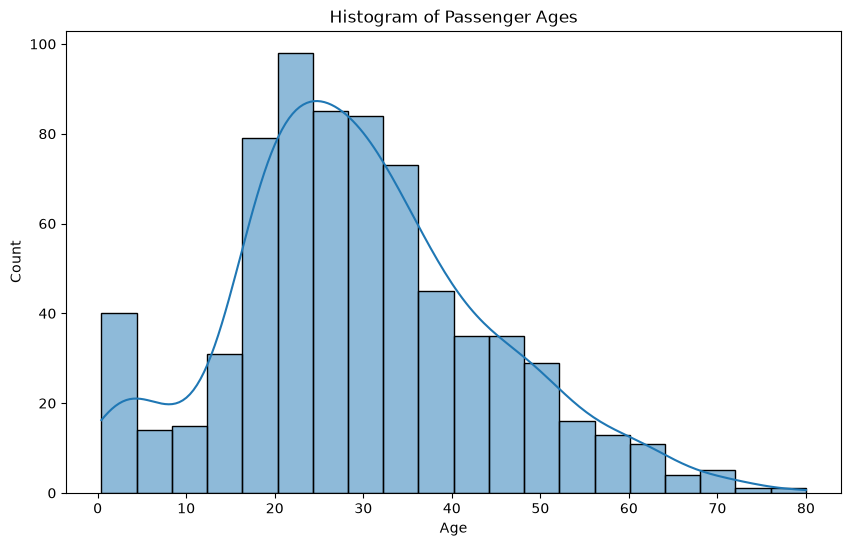

In [61]:
# Create a histogram of passenger ages

plt.figure(figsize=(10, 6))
sns.histplot(data=titanic_data, x = "Age", bins=20, kde=True)
plt.title('Histogram of Passenger Ages')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

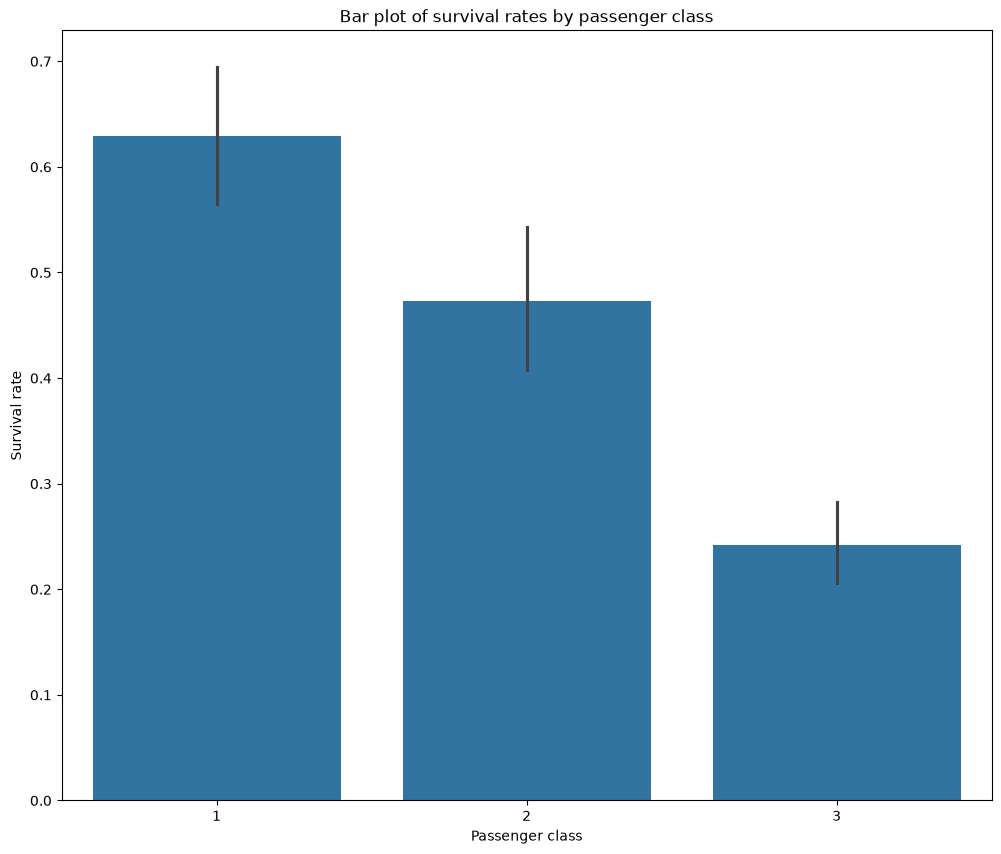

In [66]:
# Create a bar plot of survival rates by passenger class
plt.figure(figsize=(12,10))
sns.barplot(data=titanic_data, x="Pclass", y="Survived")
plt.title("Bar plot of survival rates by passenger class")
plt.xlabel("Passenger class")
plt.ylabel("Survival rate")
plt.show()

In [ ]:
# TODO: Create a heatmap of correlation between numerical features
# plt.figure(figsize=(12, 10))
# ...
# plt.title('Correlation Heatmap of Numerical Features')
# plt.show()

# TODO: Create a pair plot of 'Age', 'Fare', 'SibSp', and 'Parch', colored by 'Survived'
# ...

# Task 8: Analyze survival rates

# TODO: Calculate and display survival rates by sex
# survival_by_sex = ...

# TODO: Calculate and display survival rates by passenger class
# survival_by_class = ...

# Task 9: Analyze age distribution

# TODO: Create a box plot of age distribution by passenger class and sex
# plt.figure(figsize=(12, 6))
# ...
# plt.title('Age Distribution by Passenger Class and Sex')
# plt.show()

# Task 10: Analyze fare distribution

# TODO: Create a violin plot of fare distribution by passenger class and survival status
# plt.figure(figsize=(12, 6))
# ...
# plt.title('Fare Distribution by Passenger Class and Survival Status')
# plt.show()

print("EDA tasks completed.")